In [15]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [16]:
# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/CV_all_rows_codes_incl_no_mods.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_all_rows_codes_incl_no_mods.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)
print("CV_rows:", CV_rows.shape)

           STATION_ID  LATITUDE  LONGITUDE                 DATE REPORT_TYPE  \
0         USM00074917   35.1170  -119.3000  1941-12-01 00:00:00         SAO   
1         USM00074917   35.1170  -119.3000  1941-12-01 01:00:00         SAO   
2         USM00074917   35.1170  -119.3000  1941-12-01 02:00:00         SAO   
3         USM00074917   35.1170  -119.3000  1941-12-01 03:00:00         SAO   
4         USM00074917   35.1170  -119.3000  1941-12-01 04:00:00         SAO   
...               ...       ...        ...                  ...         ...   
14495830  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00       FM-15   
14495831  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00       FM-15   
14495832  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00       FM-15   
14495833  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00       FM-15   
14495834  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00       FM-15   

          HourlyPrecipitation HourlyPresentWeatherT

In [17]:
# filtering based on precipiation to identify fog conditions
# filtering visibility threshold to identify outliers
CV_filtered_rows = CV_rows[
    (CV_rows["HourlyPrecipitation"] < 0.03)
    & (CV_rows["HourlyVisibility"] < 17.000)
]

print("CV_filtered_rows:", CV_filtered_rows.shape)

CV_filtered_rows: (10429072, 15)


In [18]:
# Exclude days from April through October (months 4-10) in CV_fog_rows
CV_filtered_rows = CV_filtered_rows[~CV_filtered_rows['month'].isin([4, 5, 6, 7, 8, 9, 10])]

print("CV_filtered_rows after removing April-October:", CV_filtered_rows.shape)

CV_filtered_rows after removing April-October: (4526168, 15)


In [19]:
#counting days measured per year per station
fog_days_year = (
    CV_filtered_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)

print(fog_days_year.head())

          STATION  year  fog_days
0  BAKERSFIELD AP  1928        66
1  BAKERSFIELD AP  1929       120
2  BAKERSFIELD AP  1930        80
3  BAKERSFIELD AP  1931       108
4  BAKERSFIELD AP  1932       152


In [20]:
# Find stations with data back to at least 1970
stations_pre1970 = (
    CV_rows.groupby('STATION')['year']
    .min()
    .loc[lambda s: s <= 1970]
    .index
    .tolist()
)

print(len(stations_pre1970), "stations with data back to at least 1970")
print(stations_pre1970)

# make dateframe with station locations
station_locations = (
    CV_rows[CV_rows['STATION'].isin(stations_pre1970)]
    .drop_duplicates(subset=['STATION'])
    .loc[:, ['STATION', 'LATITUDE', 'LONGITUDE']]
    .reset_index(drop=True)
)

23 stations with data back to at least 1970
['BAKERSFIELD AP', 'BEALE AFB', 'CASTLE AFB', 'CHICO ARMY FLYING SCHOOL', 'FRESNO', 'FRESNO CHANDLER DOWNTOWN AP', 'FRESNO YOSEMITE INTL', 'GARDNER AAF', 'HAMMER AAF', 'LEMOORE REEVES NAS', 'LIVERMORE NAS', 'MARYSVILLE AIRPORT (ASOS)', 'MODESTO AP', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO 5 ESE', 'SACRAMENTO AP ASOS', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB', 'STOCKTON AP', 'TRAVIS FIELD AFB', 'VERNALIS NAVAL AUX', 'WILLIAMS CAA AIRPORT']


In [21]:
station_year_counts = (
    CV_rows
    .drop_duplicates(subset=['STATION', 'year'])
    .groupby('STATION')['year']
    .nunique()
    .sort_values(ascending=False)
)

stations_30_years = station_year_counts[station_year_counts > 30].index.tolist()
stations_30_years_pre1970 = [s for s in stations_30_years if s in stations_pre1970]

print(len(stations_30_years), "stations with more than 30 years of data")
print("stations_30_years_pre1970:", stations_30_years_pre1970)
station_year_counts.loc[stations_30_years_pre1970]

22 stations with more than 30 years of data
stations_30_years_pre1970: ['SACRAMENTO 5 ESE', 'RED BLUFF MUNI AP', 'MODESTO AP', 'BAKERSFIELD AP', 'SACRAMENTO AP ASOS', 'STOCKTON AP', 'FRESNO YOSEMITE INTL', 'TRAVIS FIELD AFB', 'SACRAMENTO MCCLELLAN AFB', 'SACRAMENTO MATHER AFB', 'CASTLE AFB', 'BEALE AFB', 'LEMOORE REEVES NAS', 'CHICO ARMY FLYING SCHOOL', 'MARYSVILLE AIRPORT (ASOS)', 'REDDING AP', 'FRESNO', 'FRESNO CHANDLER DOWNTOWN AP']


STATION
SACRAMENTO 5 ESE               149
RED BLUFF MUNI AP              135
MODESTO AP                     113
BAKERSFIELD AP                  99
SACRAMENTO AP ASOS              96
STOCKTON AP                     85
FRESNO YOSEMITE INTL            84
TRAVIS FIELD AFB                83
SACRAMENTO MCCLELLAN AFB        80
SACRAMENTO MATHER AFB           80
CASTLE AFB                      76
BEALE AFB                       67
LEMOORE REEVES NAS              66
CHICO ARMY FLYING SCHOOL        58
MARYSVILLE AIRPORT (ASOS)       57
REDDING AP                      55
FRESNO                          42
FRESNO CHANDLER DOWNTOWN AP     32
Name: year, dtype: int64

In [22]:
# Remove stations with 200 or fewer days counted
fog_days_year_no_outliers = fog_days_year[fog_days_year["fog_days"] > 149].copy()

# Get the valid station-year combinations for merging
valid_station_years = fog_days_year_no_outliers[["STATION", "year"]]
CV_fog_rows_no_outliers = CV_filtered_rows.merge(valid_station_years, on=["STATION", "year"], how="inner")

# print to check
print("Station-years kept:", fog_days_year_no_outliers.shape[0])
print("CV_fog_rows_no_outliers:", CV_fog_rows_no_outliers.shape)

Station-years kept: 971
CV_fog_rows_no_outliers: (3888000, 15)


In [23]:
# Filter rows from the narrowed dataframe with HourlyVisibility < 1.000
low_vis_rows = CV_fog_rows_no_outliers[CV_fog_rows_no_outliers["HourlyVisibility"] < 1.000]
# low_vis_rows = CV_fog_rows_no_outliers[CV_fog_rows_no_outliers["HourlyVisibility"] < 0.403]

print("CV_fog_rows_no_outliers with HourlyVisibility < 1.000:", low_vis_rows.shape)
# print("CV_fog_rows_no_outliers with HourlyVisibility < 0.403:", low_vis_rows.shape)
# low_vis_rows.head()

CV_fog_rows_no_outliers with HourlyVisibility < 1.000: (219523, 15)


In [24]:
# add a new dataframe to count the number of low visibility fog days per year per station
# with year, month, and day as unique identifiers to avoid double counting
low_vis_fog_days_year = (
    low_vis_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)

In [25]:
# print the number of unique years for each station in low_vis_fog_days_year
station_year_counts = low_vis_fog_days_year.groupby("STATION")["year"].nunique()
stations_with_30_years = station_year_counts[station_year_counts >= 30].index

# filter low_vis_fog_days_year to only include stations with at least 30 years of data
low_vis_fog_days_year_filtered = low_vis_fog_days_year[
    low_vis_fog_days_year["STATION"].isin(stations_with_30_years)
].copy()

# print to check
print("Stations kept:", len(stations_with_30_years))
print("Filtered low_vis_fog_days_year rows:", low_vis_fog_days_year_filtered.shape)
low_vis_rows.head()

Stations kept: 14
Filtered low_vis_fog_days_year rows: (783, 3)


,STATION_ID,LATITUDE,LONGITUDE,DATE,REPORT_TYPE,HourlyPrecipitation,HourlyPresentWeatherType,HourlySkyConditions,HourlyVisibility,year,month,day,hour,minute,STATION
128,USM00074917,35.117,-119.3,1942-01-06 08:00:00,SAO,0.0,||FG,NaN,0.4,1942,1,6,8,0,GARDNER AAF
217,USM00074917,35.117,-119.3,1942-01-10 01:00:00,SAO,0.0,||FG,NaN,0.3,1942,1,10,1,0,GARDNER AAF
218,USM00074917,35.117,-119.3,1942-01-10 02:00:00,SAO,0.0,||FG,OVC:08,0.8,1942,1,10,2,0,GARDNER AAF
219,USM00074917,35.117,-119.3,1942-01-10 03:00:00,SAO,0.0,||FG,OVC:08,0.4,1942,1,10,3,0,GARDNER AAF
223,USM00074917,35.117,-119.3,1942-01-10 07:00:00,SAO,0.0,||FG,OVC:08,0.8,1942,1,10,7,0,GARDNER AAF


In [26]:
# compute low-visibility fog events from hourly CV_rows observations
low_vis_events = low_vis_rows.copy()
if low_vis_events["DATE"].dtype == object:
    low_vis_events["DATE"] = pd.to_datetime(low_vis_events["DATE"])

low_vis_events = low_vis_events.sort_values(["STATION", "DATE"])
# ensure DATE is datetime (handles object, pandas string dtype, etc.)
if not pd.api.types.is_datetime64_any_dtype(low_vis_events["DATE"]):
    low_vis_events["DATE"] = pd.to_datetime(low_vis_events["DATE"], errors="coerce")

# compute time difference within each station; treat first obs as a large gap
low_vis_events["time_diff"] = low_vis_events.groupby("STATION")["DATE"].diff()
low_vis_events["time_diff"] = low_vis_events["time_diff"].fillna(pd.Timedelta(hours=999))
low_vis_events["new_event"] = low_vis_events["time_diff"] > pd.Timedelta(hours=1.5)
low_vis_events["event_id"] = low_vis_events.groupby("STATION")["new_event"].cumsum()

# summarize events by station and event_id
event_summary = (
    low_vis_events
    .groupby(["STATION", "event_id"], as_index=False)
    .agg(
        start=("DATE", "min"),
        end=("DATE", "max"),
        year=("year", "first"),
        month=("month", "first"),
        duration_hours=("event_id", "size"),
    )
)

# compute year_month for event_summary
event_summary["year_month"] = pd.to_datetime(
    dict(year=event_summary["year"], month=event_summary["month"], day=1)
)

# compute monthly low visibility days for each station
monthly_low_vis_days = (
    low_vis_events
    .drop_duplicates(subset=["STATION", "year", "month", "day"])
    .groupby(["STATION", "year", "month"], as_index=False)
    .size()
    .rename(columns={"size": "low_vis_days"})
)

# compute monthly event statistics for each station
event_monthly = (
    event_summary
    .groupby(["STATION", "year", "month"], as_index=False)
    .agg(
        avg_event_duration_hours=("duration_hours", "mean"),
        n_events=("duration_hours", "size"),
    )
    .merge(monthly_low_vis_days, on=["STATION", "year", "month"], how="left")
)

# compute year_month for event_monthly
event_monthly["year_month"] = pd.to_datetime(
    dict(year=event_monthly["year"], month=event_monthly["month"], day=1)
)

# compute annual event statistics for each station
annual_event_stats = (
    event_monthly
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        avg_event_duration_hours=("avg_event_duration_hours", "mean"),
        total_events=("n_events", "sum"),
        avg_monthly_low_vis_days=("low_vis_days", "mean"),
    )
)

# merge low_vis_fog_days_year_filtered with annual_event_stats to compare fog days and event statistics
annual_compare = low_vis_fog_days_year_filtered.merge(
    annual_event_stats,
    on=["STATION", "year"],
    how="left"
)

# print to check
print(annual_compare.head())

          STATION  year  fog_days  avg_event_duration_hours  total_events  \
0  BAKERSFIELD AP  1932        15                  2.666667            17   
1  BAKERSFIELD AP  1933        18                  5.075000            26   
2  BAKERSFIELD AP  1934        39                  3.549366            60   
3  BAKERSFIELD AP  1935        21                  2.773810            30   
4  BAKERSFIELD AP  1936        14                  3.113636            20   

   avg_monthly_low_vis_days  
0                      5.00  
1                      6.00  
2                      9.75  
3                      5.25  
4                      2.80  


In [37]:
# # Analyze gaps between consecutive low-visibility fog events (by station)

# event_gaps = event_summary.copy()

# # Ensure datetime types
# event_gaps["start"] = pd.to_datetime(event_gaps["start"], errors="coerce")
# event_gaps["end"] = pd.to_datetime(event_gaps["end"], errors="coerce")

# # Sort and compute next event start per station
# event_gaps = event_gaps.sort_values(["STATION", "start"]).reset_index(drop=True)
# event_gaps["next_start"] = event_gaps.groupby("STATION")["start"].shift(-1)

# # Gap duration (hours) from end of current event to start of next event
# event_gaps["gap_hours"] = (event_gaps["next_start"] - event_gaps["end"]).dt.total_seconds() / 3600.0

# # Keep valid gaps only
# event_gaps = event_gaps[event_gaps["gap_hours"].notna() & (event_gaps["gap_hours"] >= 0)].copy()

# # Classify the "nature" of gaps
# bins = [-0.001, 6, 24, 72, 336, 24 * 120, np.inf]
# labels = [
#     "very_short_(<=6h)",
#     "intra_day_(6-24h)",
#     "multi_day_(1-3d)",
#     "synoptic_(3-14d)",
#     "extended_(2-4mo)",
#     "seasonal_(>4mo)"
# ]
# event_gaps["gap_type"] = pd.cut(event_gaps["gap_hours"], bins=bins, labels=labels)

# # Flag likely off-season transitions (Mar -> Nov)
# event_gaps["off_season_transition"] = (
#     (event_gaps["end"].dt.month == 3) & (event_gaps["next_start"].dt.month == 11)
# )

# # Overall summary
# gap_summary = (
#     event_gaps.groupby("gap_type", observed=True)
#     .agg(
#         n_gaps=("gap_hours", "size"),
#         pct=("gap_hours", lambda s: 100 * len(s) / len(event_gaps)),
#         median_hours=("gap_hours", "median"),
#         mean_hours=("gap_hours", "mean")
#     )
#     .sort_values("n_gaps", ascending=False)
# )

# # Station-level median gap characteristics
# station_gap_stats = (
#     event_gaps.groupby("STATION", as_index=False)
#     .agg(
#         n_gaps=("gap_hours", "size"),
#         median_gap_hours=("gap_hours", "median"),
#         p90_gap_hours=("gap_hours", lambda s: s.quantile(0.90)),
#         off_season_transitions=("off_season_transition", "sum")
#     )
#     .sort_values("median_gap_hours", ascending=False)
# )

# print("Overall gap-type summary:")
# print(gap_summary)

# print("\nTop 10 stations by median gap length:")
# print(station_gap_stats.head(10))

# # Optional quick look at distribution
# plt.figure(figsize=(8, 4))
# event_gaps["gap_hours"].clip(upper=24 * 200).hist(bins=80)
# plt.xlabel("Gap between fog events (hours)")
# plt.ylabel("Count")
# plt.title("Distribution of inter-event fog gaps (clipped at 200 days)")
# plt.tight_layout()
# plt.show()

In [38]:
# Aggregate hourly visibility by station, year, and hour of day
vis_plot_df = CV_filtered_rows[["STATION", "year", "hour", "HourlyVisibility"]].copy()
vis_plot_df["HourlyVisibility"] = pd.to_numeric(vis_plot_df["HourlyVisibility"], errors="coerce")
vis_plot_df["hour"] = pd.to_numeric(vis_plot_df["hour"], errors="coerce")
vis_plot_df = vis_plot_df.dropna(subset=["HourlyVisibility", "hour"])

hourly_visibility_by_station_year_hour = (
    vis_plot_df
    .groupby(["STATION", "year", "hour"], as_index=False)["HourlyVisibility"]
    .mean()
    .rename(columns={"HourlyVisibility": "mean_visibility"})
)

#only include stations with at least 30 years of data
stations = (
    hourly_visibility_by_station_year_hour.groupby("STATION")["year"].nunique()
    .loc[lambda x: x >= 30]
    .index
    .sort_values()
)

for station in stations:
    station_data = hourly_visibility_by_station_year_hour[
        hourly_visibility_by_station_year_hour["STATION"] == station
    ].copy()

    if station_data.empty:
        continue

    pivot = (
        station_data
        .pivot(index="hour", columns="year", values="mean_visibility")
        .sort_index()
    )

    if pivot.empty:
        continue

    # fig, ax = plt.subplots(figsize=(12, 5))
    # colors = plt.cm.viridis(np.linspace(0, 1, len(pivot.columns)))

    # for year, color in zip(pivot.columns, colors):
    #     ax.plot(
    #         pivot.index,
    #         pivot[year].values,
    #         label=str(year),
    #         color=color,
    #         lw=1.2,
    #         alpha=0.8,
    #     )

    # ax.set_title(f"{station} - mean HourlyVisibility by hour of day")
    # ax.set_xlabel("Hour of day")
    # ax.set_ylabel("Mean HourlyVisibility")
    # ax.set_xticks(range(0, 24))
    # ax.set_xlim(0, 23)
    # ax.grid(True, alpha=0.3)

    # if len(pivot.columns) <= 20:
    #     ax.legend(title="year", loc="best", fontsize=8)
    # else:
    #     ax.legend(title="year", loc="best", fontsize=6, ncol=2)

    # plt.tight_layout()
    # plt.show()
    # plt.close(fig)

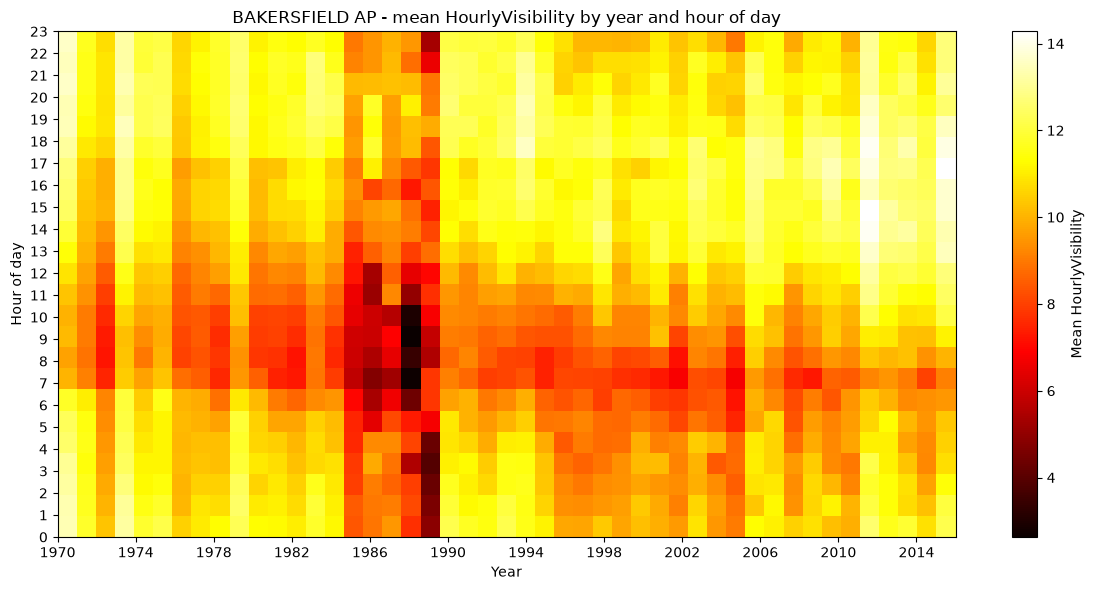

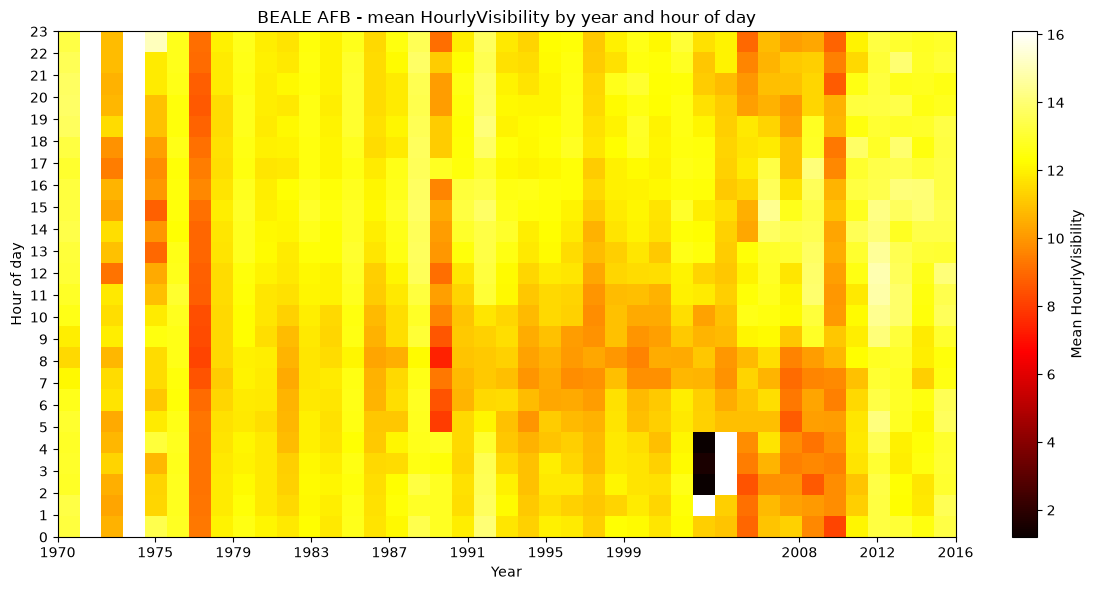

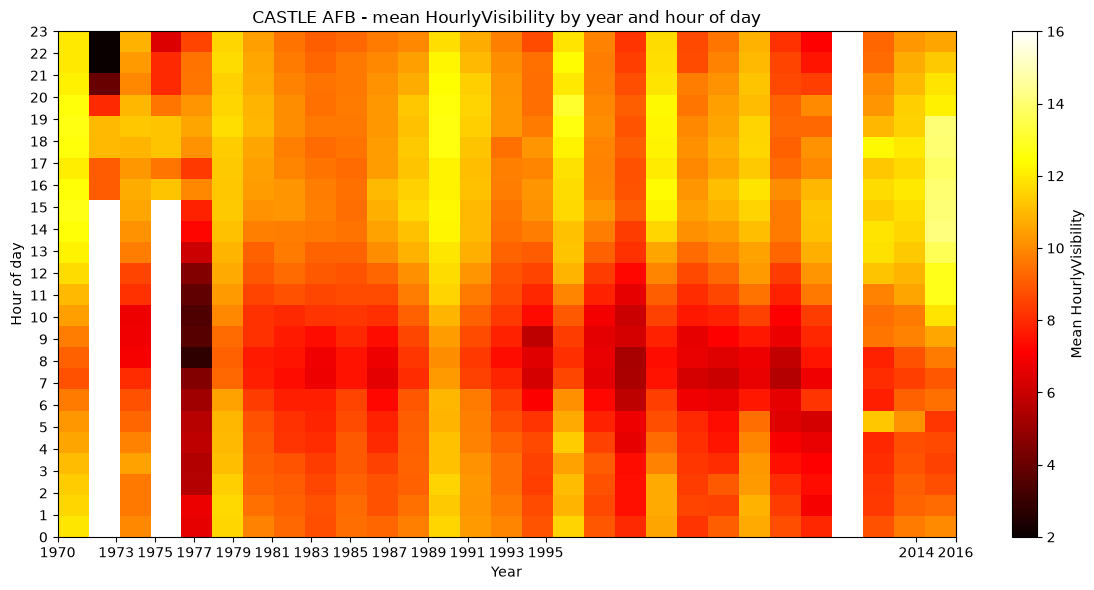

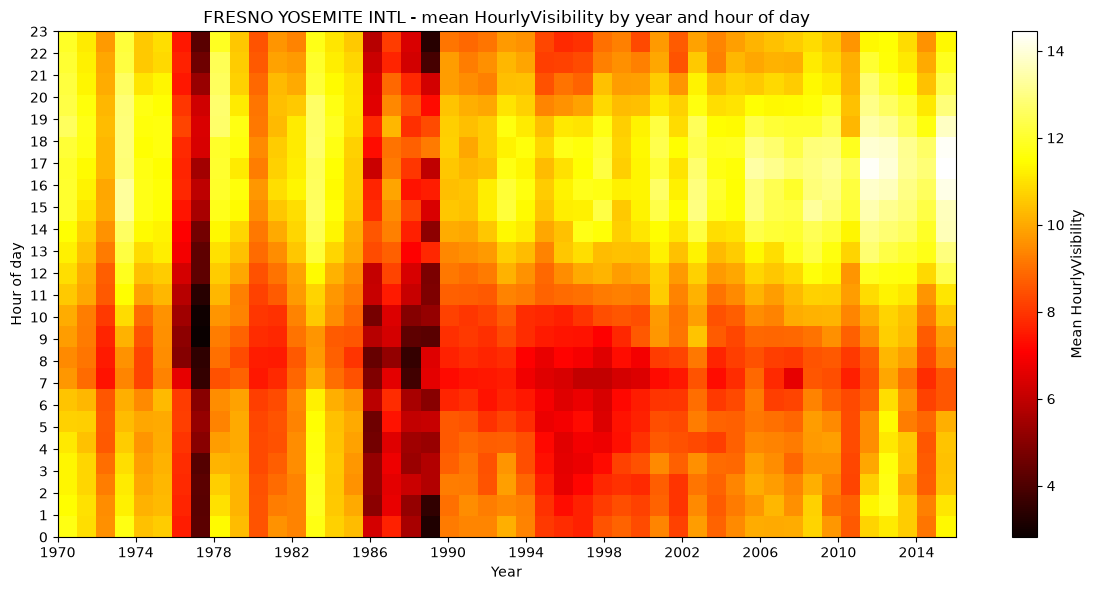

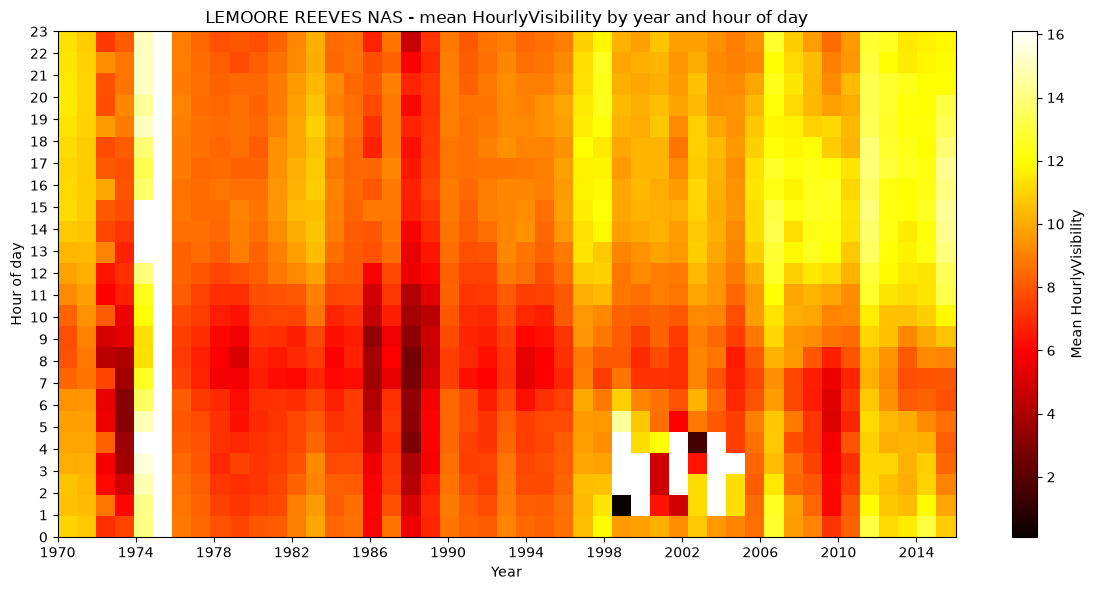

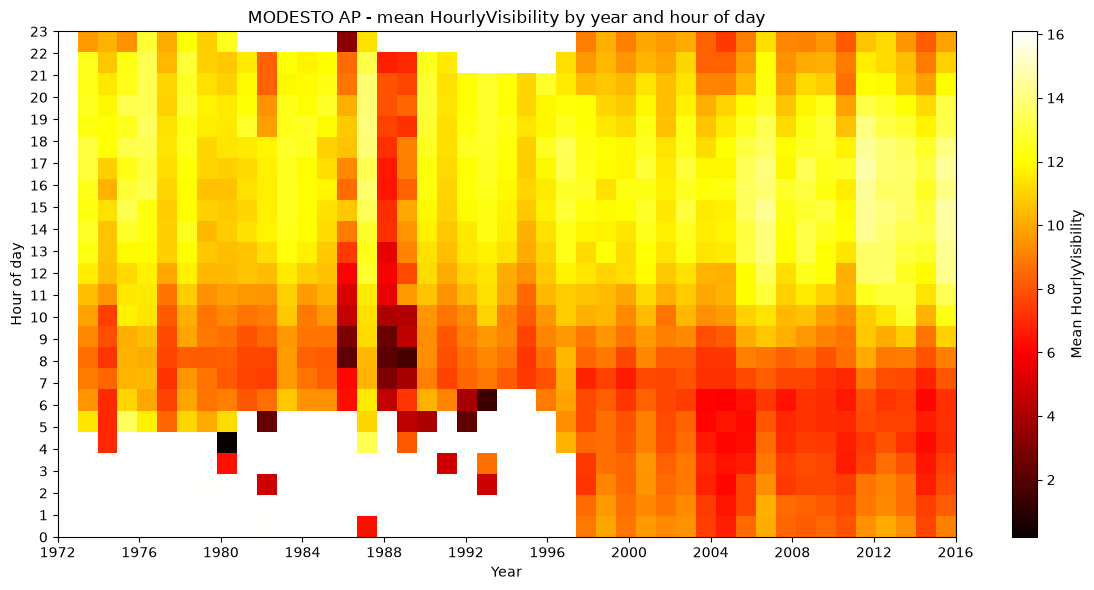

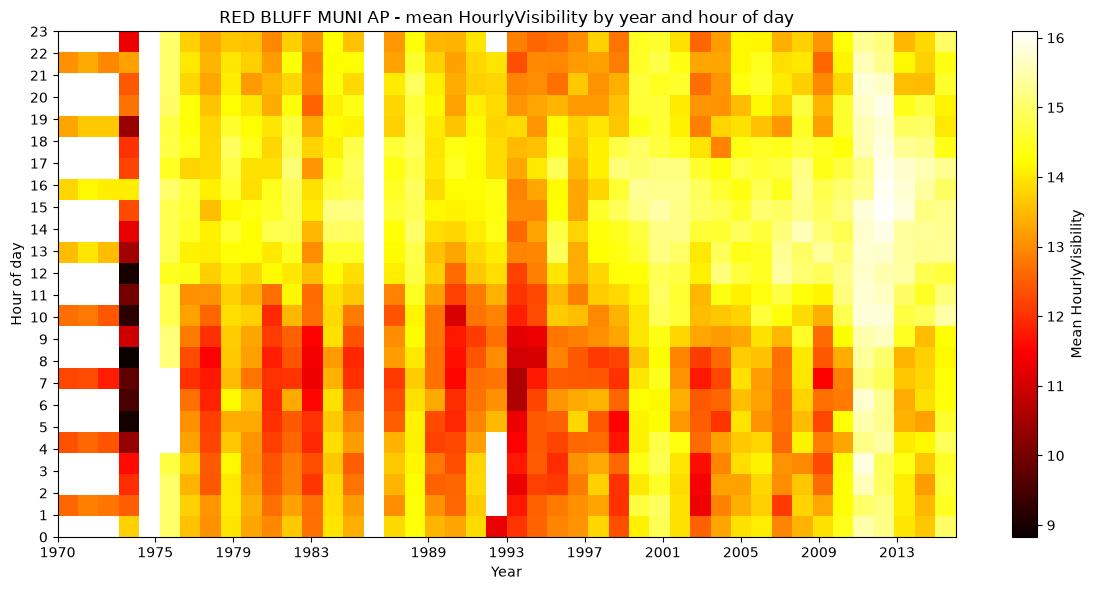

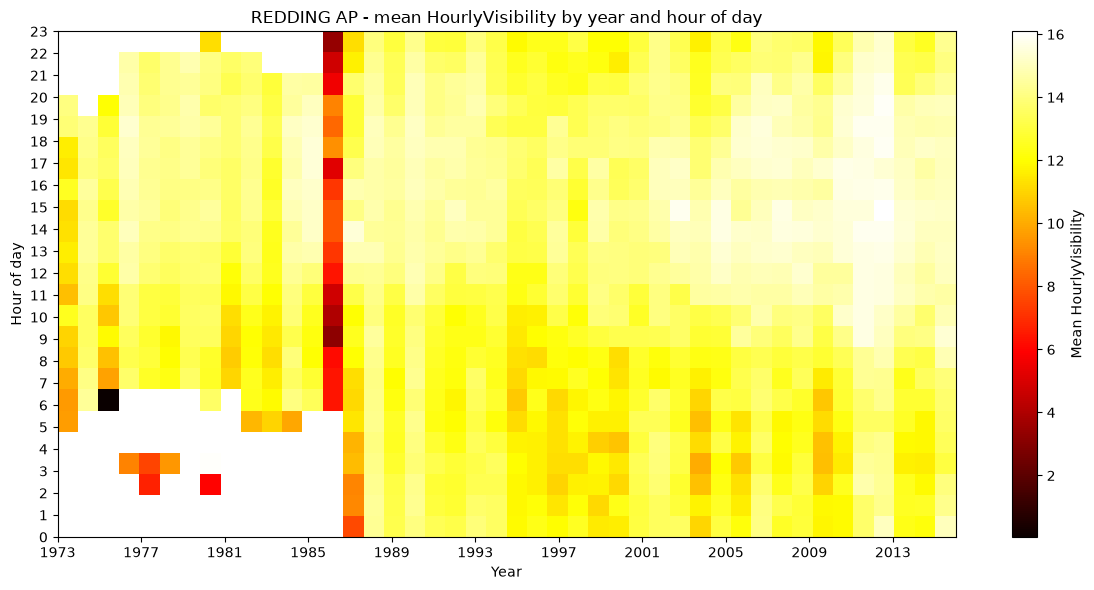

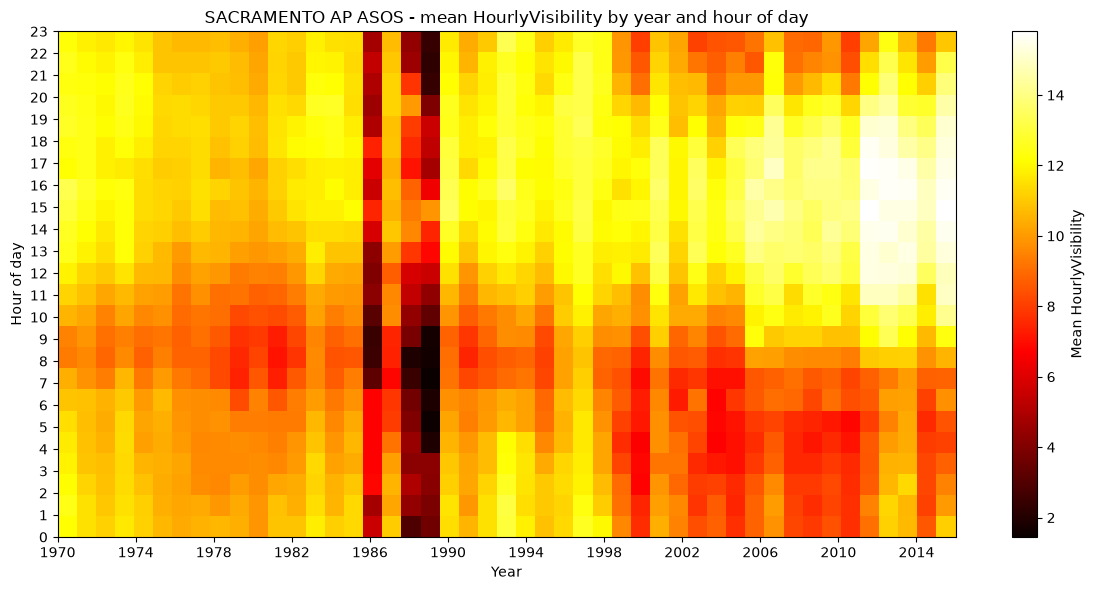

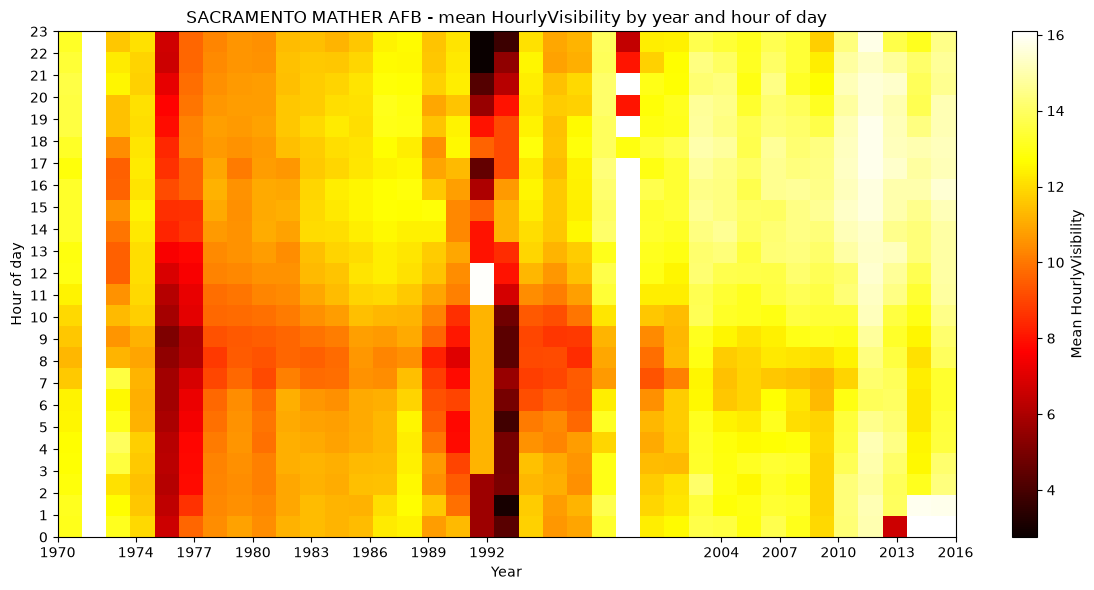

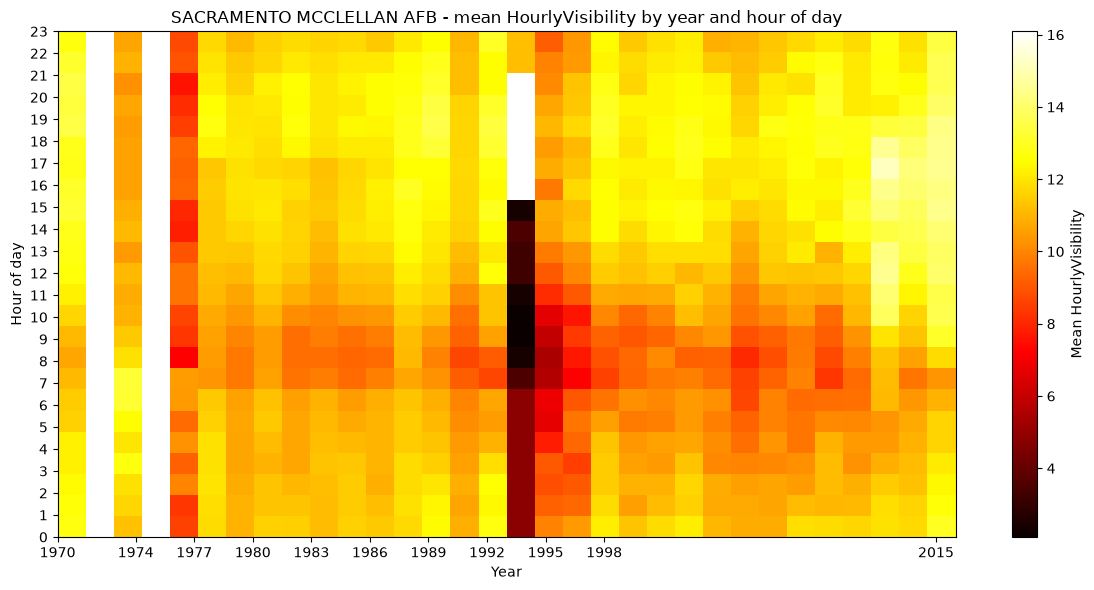

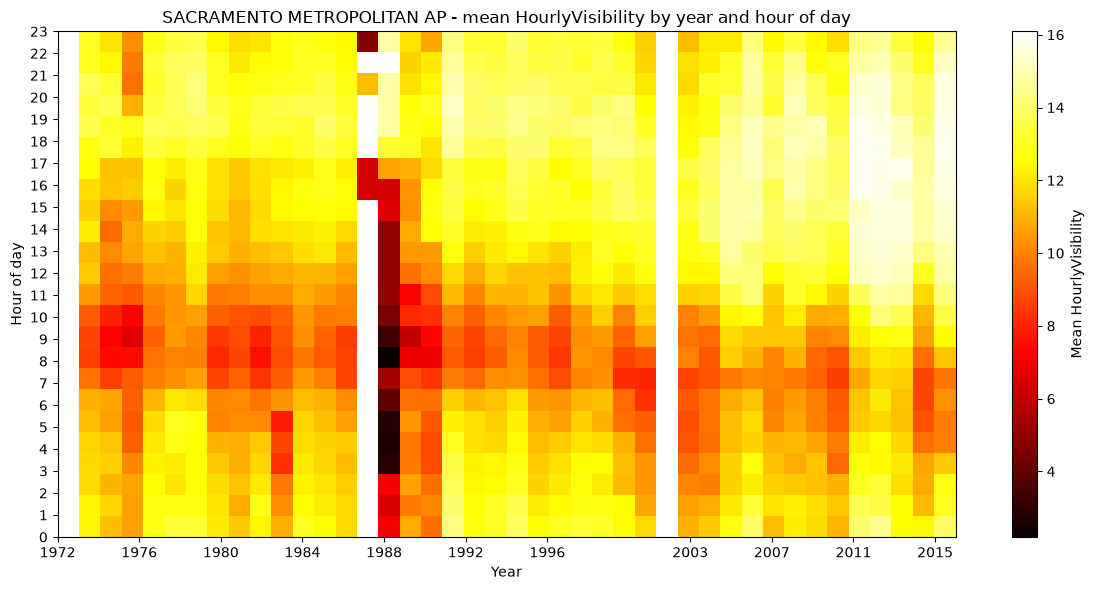

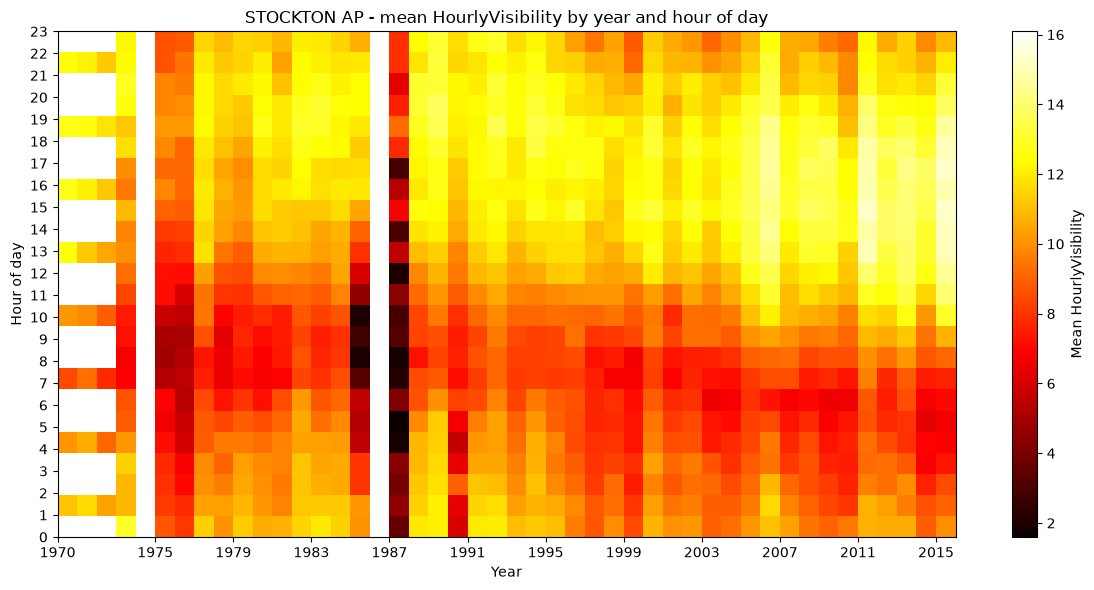

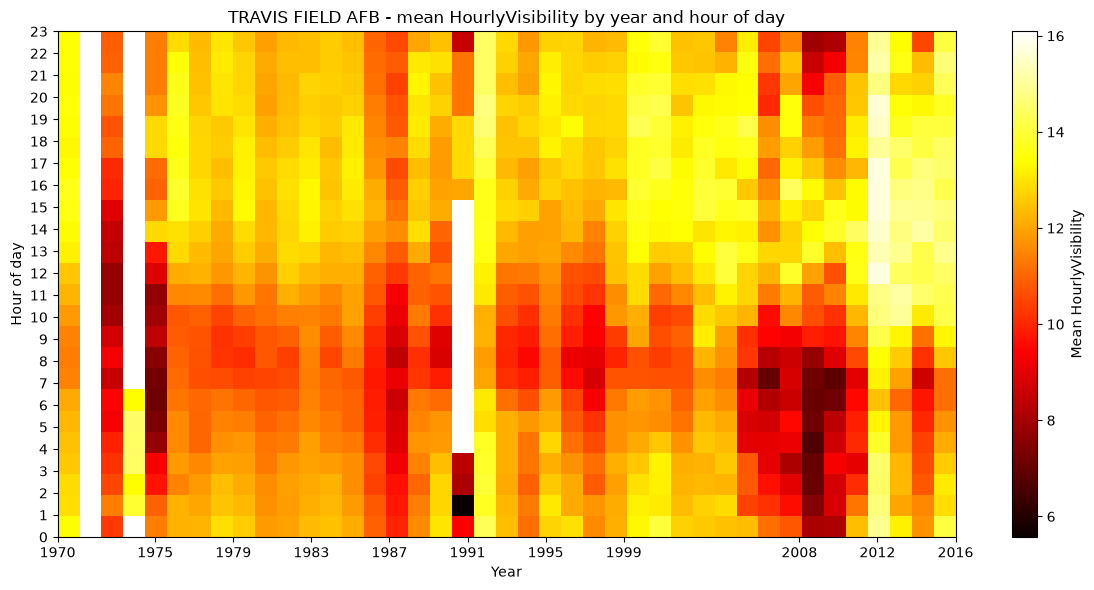

In [43]:
for station in stations:
    station_data = hourly_visibility_by_station_year_hour[
        hourly_visibility_by_station_year_hour["STATION"] == station
    ].copy()
    # only use years from 1970 to 2016
    station_data = station_data[(station_data["year"] >= 1970) & (station_data["year"] <= 2016)]


    if station_data.empty:
        continue

    pivot2 = (
        station_data
        .pivot(index="hour", columns="year", values="mean_visibility")
        .sort_index()
    )

    if pivot2.empty:
        continue

    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.imshow(
        pivot2.values,
        aspect="auto",
        origin="lower",
        cmap="hot",
        extent=[pivot2.columns.min(), pivot2.columns.max(), pivot2.index.min(), pivot2.index.max()],
    )

    ax.set_title(f"{station} - mean HourlyVisibility by year and hour of day")
    ax.set_xlabel("Year")
    ax.set_ylabel("Hour of day")
    ax.set_yticks(range(0, 24))
    ax.set_xticks(sorted(pivot2.columns.unique())[::max(1, len(pivot2.columns) // 10)])
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Mean HourlyVisibility")

    plt.tight_layout()
    plt.show()
    plt.close(fig)